# Federated learning: ECI 2026 Project

This is the [final optional project](http://ichatz.me/Site/FederatedLearningECI2026Project) for the course Federated Learning taught by [Ioannis Chatzigiannakis](http://ichatz.me/Site/Home) at the Escuelas de Ciencias Informáticas in July 2026. 

The course itself followed the idea of dataset descentralization to perform Machine Learning to avoid providing sensitive (raw) data to privately-owned servers, during the course we also tackled the problems regarding non-IIDness, adversarial clients, privacy & security. 

It was overall a fantastic course that really sparked my interest in what is usually an underlooked aspect of digitalization, how we protect our data & the trust we place in big corporations.

With that being said, the objective here is to simulate a small federated learning scenario


## SETUP

First we need to install Tensorflow (and it's datasets) & MatPlotLib 

In [2]:
!pip install -q matplotlib
!pip install -q tensorflow tensorflow_probability[tf]
!pip install -q numpy
!pip3 install -q torch torchvision --index-url https://download.pytorch.org/whl/cpu
!pip install -q scikit-learn

Then we import it

In [3]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torchvision
import tensorflow_probability as tfp
import numpy as np
import torch.nn as nn
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import copy
import math

## Dataset

I'm going to be using [CIFAR10](https://www.tensorflow.org/datasets/catalog/cifar10?hl=es), a dataset containing 60000 32x32 colour images uniformly distributed amongst 10 classes. 

We want an equal label-wise distribution using a **60/10/30** split for training, validation & test, for that reason we must stratify the split using the labels 

> The dataset itself is pre-split so we need to recombine it and then split it

In [4]:
train_data = torchvision.datasets.CIFAR10(root="data", train=True, download=True)
test_data = torchvision.datasets.CIFAR10(root="data", train=False, download=True)

train_labels = torch.from_numpy(np.array(train_data.targets)).long()
test_labels = torch.from_numpy(np.array(test_data.targets)).long()

train_images = torch.from_numpy(train_data.data)
test_images = torch.from_numpy(test_data.data)

train_images_normalized = (train_images).float() / 255.0   
train_images_normalized = train_images_normalized.permute(0, 3, 1, 2)                 # (N, H, W, C) -> (N, C, H, W)

test_images_normalized = (test_images).float() / 255.0   
test_images_normalized = test_images_normalized.permute(0, 3, 1, 2)                 # (N, H, W, C) -> (N, C, H, W)

train_labels = (train_labels).long()   
test_labels = (test_labels).long()     

images = torch.cat([train_images_normalized, test_images_normalized], dim=0)
labels = torch.cat([train_labels, test_labels], dim=0)

# First we take the 60% split
X_train, X_temp, Y_train, y_temp = train_test_split(
    images, labels,
    test_size=0.40,      
    random_state=42,
    stratify=labels   
)

# Then we split the remaining 40% of the dataset into 10/30
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.75,      
    random_state=42,
    stratify=y_temp      
)

train_data = TensorDataset(X_train, Y_train)
val_data   = TensorDataset(X_val, Y_val)
test_data  = TensorDataset(X_test, Y_test)

print(train_data.tensors[0].shape)  
print(train_data.tensors[1].shape)


torch.Size([36000, 3, 32, 32])
torch.Size([36000])


### Dataset Analysis

Now we can plot and visualize some of the data distribution, in particular we can see

1.  Histogram of the classes
2.  Few samples

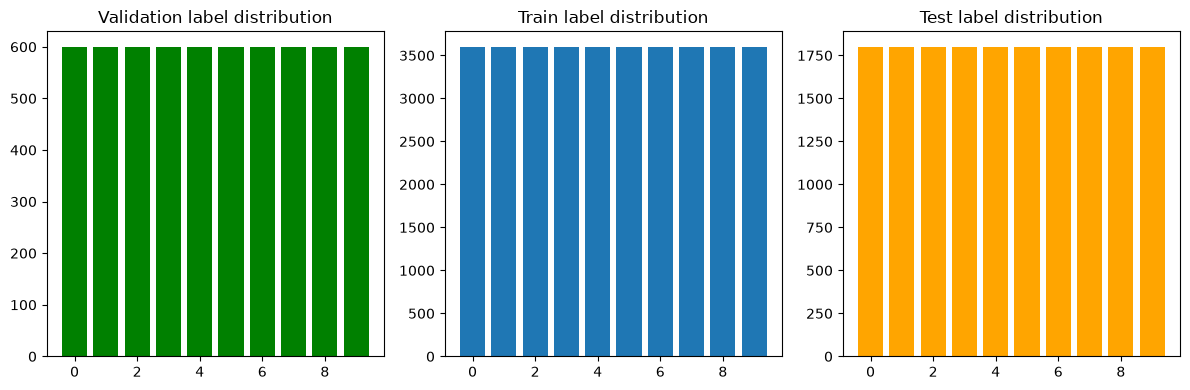

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].bar(np.unique_counts(Y_val).values, np.unique_counts(Y_val).counts, color="green")
axes[0].set_title("Validation label distribution")
axes[1].bar(np.unique_counts(Y_train).values, np.unique_counts(Y_train).counts)
axes[1].set_title("Train label distribution")
axes[2].bar(np.unique_counts(Y_test).values, np.unique_counts(Y_test).counts, color="orange")
axes[2].set_title("Test label distribution")

plt.tight_layout()
plt.show()

As we can see there is no quantity skewness because all labels have exactly 6000 samples (although we will split it into non-IID scenarios).

Let's visualize some samples of the images to get a general idea of what they look like

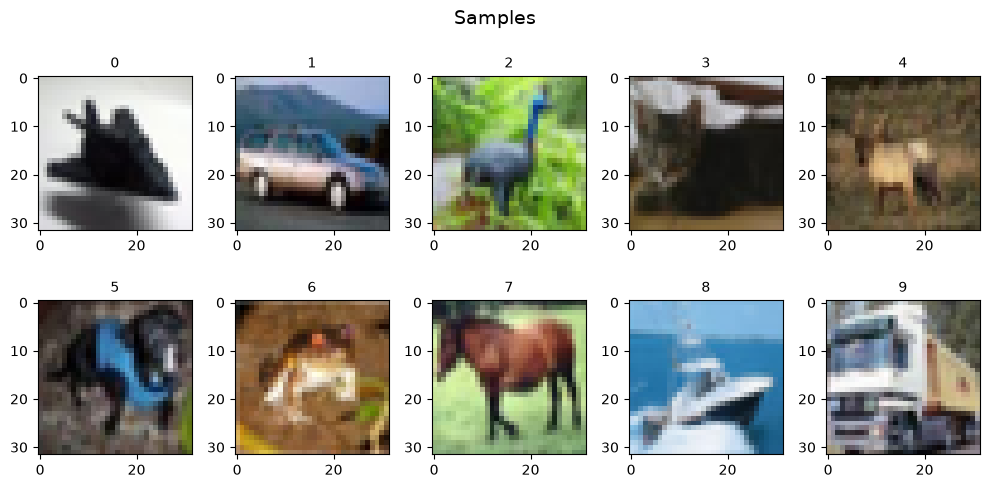

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

axes_flat = axes.flatten()

for i in range(10):
    j = 0
    while train_labels[j] != i:
        j += 1
        
    if j < len(train_labels):
        ax = axes_flat[i]
        ax.imshow(train_images[j])
        ax.set_title(f"{train_labels[j]}", fontsize=10)

plt.suptitle("Samples", fontsize=14)
plt.tight_layout()
plt.show()

## Centralized Baseline

As we attempt to showcase the effectiveness of Federated Learning (& the challenges it poses) we need a baseline for comparison, in this case the obvious thing to do is to have a standard centralized model. 

### Model construction

Now we will build a 2D Sequential Convolutional Neural Network 

<details>
<summary><b>Sources</b></summary>

* Model:    
    -   [Sequential CNNs](https://docs.pytorch.org/docs/2.13/generated/torch.nn.Sequential.html)
* Layers: 
    -   [Conv2D](https://docs.pytorch.org/docs/2.13/generated/torch.nn.Conv2d.html#torch.nn.Conv2d)
    -   [AveragePooling2D](https://docs.pytorch.org/docs/2.13/generated/torch.nn.AvgPool2d.html#torch.nn.AvgPool2d)
    -   [Flatten](https://docs.pytorch.org/docs/2.13/generated/torch.nn.Flatten.html#torch.nn.Flatten)
    -   [Linear (Dense)](https://docs.pytorch.org/docs/2.13/generated/torch.nn.Linear.html#torch.nn.Linear)
    -   [Dropout](https://docs.pytorch.org/docs/2.13/generated/torch.nn.Dropout.html#torch.nn.Dropout)
*   Activation Functions:
    -   [softmax](https://docs.pytorch.org/docs/2.13/generated/torch.nn.Softmax.html)
    -   [relu](https://docs.pytorch.org/docs/2.13/generated/torch.nn.ReLU.html)

</details>

We define our model's layers, looking at the dataset's shape

In [7]:
print(train_data.tensors[0].shape) #X shape
print(train_data.tensors[1].shape) #Y shape

torch.Size([36000, 3, 32, 32])
torch.Size([36000])


In [8]:
initial_model = nn.Sequential(

    #Feature Extraction
    nn.Conv2d(3, 8, (7,7), padding="same", stride=1), #3 channels (image has color, otherwise it'd be 1 channel?)
    nn.ReLU(),
    nn.AvgPool2d(kernel_size=(2,2)),
    nn.Conv2d(8, 16, (5,5), padding="same", stride=1),
    nn.ReLU(),
    nn.AvgPool2d(kernel_size=(2,2)),
    nn.Conv2d(16, 32, (3,3), padding="same", stride=1),
    nn.ReLU(),

    #Classifier
    nn.Flatten(), 
    nn.Dropout(p=0.3),
    nn.Linear(2048, 128), #value 2048 is because of 32x32x32x3 / 2 / 2 
    nn.Dropout(p=0.3),
    nn.Linear(128, 64),
    nn.Linear(64,10),
    nn.LogSoftmax(dim=1)
)

### Train & Test steps

Now with our model properly defined we have to define what training and testing means

Training will take each (image,label) tuple and make the model predict the label, after that we calculate the loss with the truth and then perform backpropagation.

Testing will also take (image, label) tuples, predict a label, validate the result and finally calculate the overall guess rate 

In [9]:


def train(model, optimizer, dataLoader, loss_fn):
    model.train()
    total_loss = 0
    dataset_size = len(dataLoader.dataset)
    for (X, y) in (dataLoader):

        # Predict then calculate loss
        pred = model(X)

        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        #Calculate loss 
        total_loss += loss.item() * X.size(0)

    avg_loss = total_loss/dataset_size

    return model, avg_loss

def test(model, dataLoader, loss_fn):
    model.eval()
    total_loss = 0
    correct = 0
    dataset_size = len(dataLoader.dataset)

    #.no_grad makes the model not learn from the passes 
    with torch.no_grad():
        for X, y in dataLoader:
            #Predict & if it's right add it to the guess count
            pred = model(X)
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

            #Calculate loss 
            loss = loss_fn(pred, y)
            total_loss += loss.item() * X.size(0)

    avg_loss = total_loss / dataset_size
    accuracy = correct / dataset_size

    return (accuracy, avg_loss)



### Model Training 

With all pieces in place we can now perform an optimized training routine that will track accuracy over the validation set and restore the best weights if no improvements are seen after 3 epochs, we will utilize 2 optimizers and compare the results 

In [10]:
def run_model(model, optimizer, epochs, train_dataloader, val_dataloader):

    best_model = copy.deepcopy(model)
    best_model_accuracy = 0
    stall_count = 0
    train_accAndloss_arr = []
    val_accAndloss_arr = []

    for t in range(epochs):
        model, current_loss = train(model, optimizer, train_dataloader, nn.NLLLoss())  #We train the model
        (model_accuracy, current_loss) = test(model, val_dataloader, nn.NLLLoss())    #Get it's validation accuracy

        val_accAndloss_arr.append((model_accuracy,current_loss))    
        train_accAndloss_arr.append(test(model, train_dataloader, nn.NLLLoss()))        #Calculate accuracy on train dataset (for over/underfitting)

        if(model_accuracy < best_model_accuracy):
            stall_count += 1    
        else:
            best_model = copy.deepcopy(model)                            
            best_model_accuracy = model_accuracy
            stall_count = 0

        if(stall_count == 3):
            return train_accAndloss_arr, val_accAndloss_arr

    return train_accAndloss_arr, val_accAndloss_arr


We define a common ground: the number of epochs and the datasets (both for training and validation)

In [11]:
epochs = 100

train_dataloader = DataLoader(train_data, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size=32, shuffle=True)

The Adam model

In [12]:
Adam_model = copy.deepcopy(initial_model)
Adam_optimizer = torch.optim.Adam(Adam_model.parameters())
Adam_train_metrics, Adam_val_metrics = run_model(Adam_model, Adam_optimizer, epochs=epochs, train_dataloader=train_dataloader, val_dataloader=val_dataloader)

Then the SGD model

In [13]:
SGD_model = copy.deepcopy(initial_model)
SGD_optimizer = torch.optim.SGD(SGD_model.parameters(), momentum=0.9)
SGD_train_metrics, SGD_val_metrics = run_model(SGD_model, SGD_optimizer, epochs=epochs, train_dataloader=train_dataloader, val_dataloader=val_dataloader)

## Metrics

Once both models have been trained we can compare their metrics

### Accuracy & Loss Trends

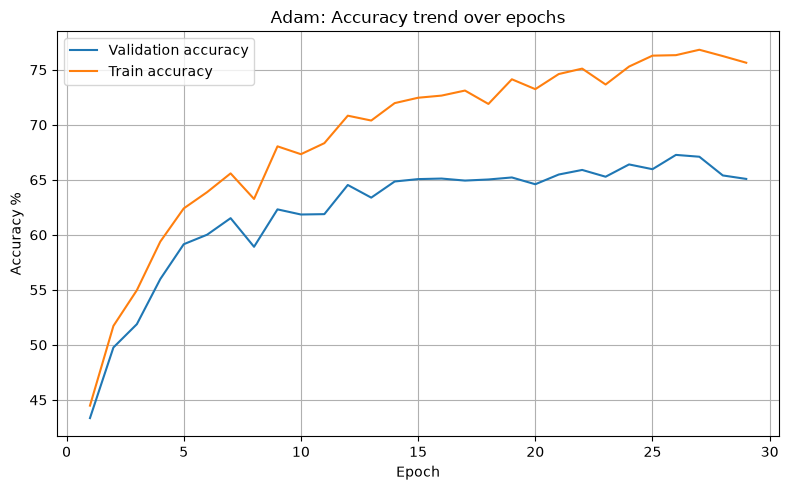

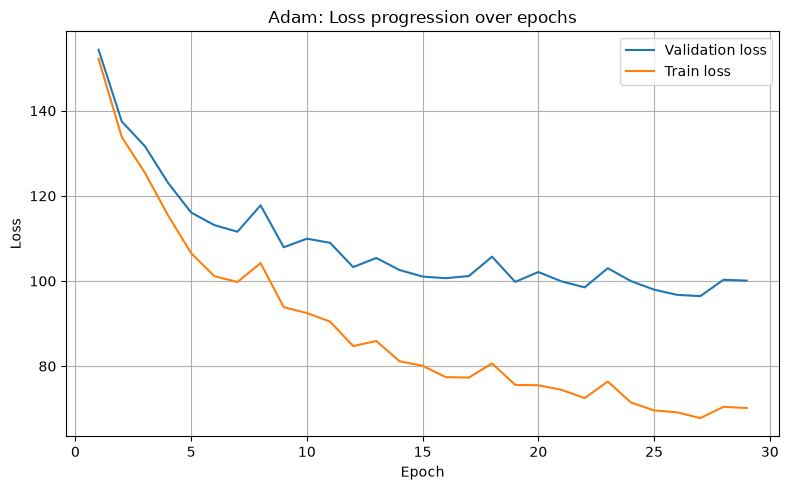

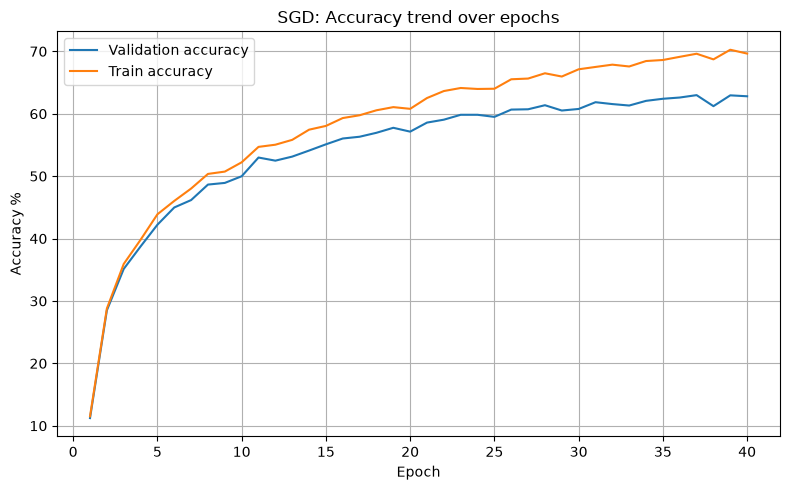

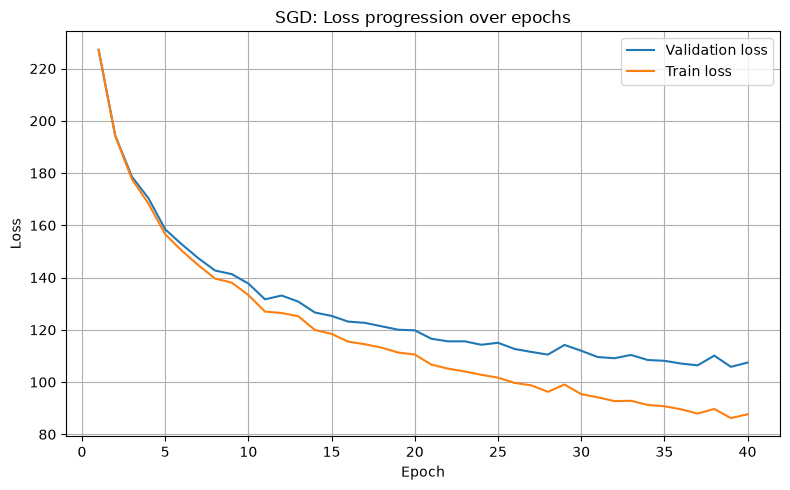

In [14]:
import matplotlib.pyplot as plt


Adam_val_acc = [acc * 100 for (acc, _) in Adam_val_metrics]
Adam_val_loss = [loss * 100 for (_, loss) in Adam_val_metrics]
Adam_train_acc = [acc * 100 for (acc, _) in Adam_train_metrics]
Adam_train_loss = [loss * 100 for (_, loss) in Adam_train_metrics]


SGD_val_acc = [acc * 100 for (acc, _) in SGD_val_metrics]
SGD_val_loss = [loss * 100 for (_, loss) in SGD_val_metrics]
SGD_train_acc = [acc * 100 for (acc, _) in SGD_train_metrics]
SGD_train_loss = [loss * 100 for (_, loss) in SGD_train_metrics]

adam_epoch_range = range(1, len(Adam_val_metrics)+1)
sgd_epoch_range = range(1, len(SGD_val_metrics)+1)

# Adam Accuracy
plt.figure(figsize=(8, 5))
plt.plot(adam_epoch_range, Adam_val_acc, label='Validation accuracy')
plt.plot(adam_epoch_range, Adam_train_acc, label='Train accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy %')
plt.title('Adam: Accuracy trend over epochs')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Adam Loss
plt.figure(figsize=(8, 5))
plt.plot(adam_epoch_range, Adam_val_loss, label='Validation loss')
plt.plot(adam_epoch_range, Adam_train_loss, label='Train loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Adam: Loss progression over epochs')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# SGD Acccyracy
plt.figure(figsize=(8, 5))
plt.plot(sgd_epoch_range, SGD_val_acc, label='Validation accuracy')
plt.plot(sgd_epoch_range, SGD_train_acc, label='Train accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy %')
plt.title('SGD: Accuracy trend over epochs')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# SGD Loss
plt.figure(figsize=(8, 5))
plt.plot(sgd_epoch_range, SGD_val_loss, label='Validation loss')
plt.plot(sgd_epoch_range, SGD_train_loss, label='Train loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('SGD: Loss progression over epochs')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Confusion Matrix

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_cm(model, dataLoader):
    model.eval()
    predictions = []
    y_test = []
    #.no_grad makes the model not learn from the passes 
    with torch.no_grad():
        for X, y in dataLoader:
            #Predict & if it's right add it to the guess count
            pred = model(X)
            predictions.append(pred)
            y_test.append(y)

    cm = confusion_matrix(y_test, predictions)
    ConfusionMatrixDisplay(cm).plot()


## Federated Models

Now we reach the point were we can start creating the federated environment, splitting the dataset and training the local models to simulate a federated context.

### Simulating Non-IID-ness

Real clients will never achieve IID-ness over the dataset, meaning that some sort label-skewness is always present and in order to achieve that we'll perform a Dirichlet-based label-skew partition. 

#### FedArtML label-skew protocol


This entails setting up a distribution vector for each of the 10 classes present in our dataset, for our case study we will simulate $K=10$ clients and analyze 4 different concentrations 

$\alpha = 1000,1,0.5, 0.1$

In [16]:
K = 10

tfd = tfp.distributions

alphas = {
    1000: [1000.0]*10,
    1: [1]*10,
    0.5: [0.5]*10,
    0.1: [0.1]*10
}

alphas_class_distributions = {}

for key, value in alphas.items():
    dist = tfd.Dirichlet(alphas[key])
    alphas_class_distributions[key] = dist.sample([10])

I0000 00:00:1788047767.442767   31687 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788047767.446639   31687 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788047767.808716   31687 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788047769.367211   31687 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONE

#### Client dataset generation

For each alpha we now have a matrix containing label-skew representations for each of the classes (that is, the distribution percentage of samples for each of the classes amongst all clients). 

We can now split the centralized dataset into "local" versions for each client 

In [17]:
def fractions_to_counts(fracs, n):  #Our Dirichlet split will represents the percentage of each class the clients will take, so we calculate the actual sample amount
    raw = [float(f) * n for f in fracs]
    counts = [int(x) for x in raw]  
    remainder = n - sum(counts)

    fractional_parts = sorted(
        range(len(raw)), key=lambda i: raw[i] - int(raw[i]), reverse=True
    )
    for i in fractional_parts[:remainder]:
        counts[i] += 1

    assert sum(counts) == n
    return counts

In [18]:
SPLITS = {"train": train_data, "test": test_data, "val": val_data}

def split_by_class(dataset):
    labels = dataset.tensors[1]
    class_datasets = [None] * 10
    for c in range(10):
        idx = torch.where(labels == c)[0]
        class_datasets[c] = torch.utils.data.Subset(dataset, idx)
    return class_datasets

classes_by_split = {name: split_by_class(ds) for name, ds in SPLITS.items()}

def build_client_datasets(class_distributions, K):
    clients_datasets = {i: {name: [] for name in SPLITS} for i in range(K)}
    client_class_counts = {i: [0] * 10 for i in range(K)}

    for class_index in range(10):
        fracs = class_distributions[class_index].numpy().tolist()
        for split_name, class_subsets in classes_by_split.items():
            subset = class_subsets[class_index]
            counts = fractions_to_counts(fracs, len(subset))
            client_subsets = torch.utils.data.random_split(subset, counts)
            for i in range(K):
                clients_datasets[i][split_name].append(client_subsets[i])
                if split_name == "train":
                    client_class_counts[i][class_index] = counts[i]

    for i in range(K):
        for split_name in SPLITS:
            clients_datasets[i][split_name] = torch.utils.data.ConcatDataset(clients_datasets[i][split_name])

    return clients_datasets, client_class_counts

alpha_clients_datasets = {}
alpha_client_class_counts = {}

for alpha, class_distributions in alphas_class_distributions.items():
    alpha_clients_datasets[alpha], alpha_client_class_counts[alpha] = build_client_datasets(class_distributions, K)

### Quantifying Non-IIDness 

We can now quantify how Non-IDD our federated datasets are by using a couple of different metrics, we will first setup a few useful variables

In [62]:
def normalize(counts):
    total = sum(counts)
    return [c / total for c in counts] if total else [0.0] * len(counts)


baseline = [0.1] * 10

client_class_distribution = {}

client_class_distribution = {
    i: {alpha: normalize(alpha_client_class_counts[alpha][i]) for alpha in alphas_class_distributions}
    for i in range(K)
}

Now for the metrics

#### 1. Hellinger Distance

$$ H(P,Q) = \frac{1}{\sqrt{2}}\sqrt{\sum^{n}_{i=1}{\Bigl(\sqrt{P(i)}-\sqrt{Q(i)}\Bigr)^2}}$$

Where near-zero Hellinger distance's value means a more IID-scenario

In [63]:
def HellingerDistance(P,Q):

    sum = 0

    for i in range(len(P)):
        sum += (P[i]**0.5 - Q[i]**0.5)**2

    return 1/(2**0.5) * sum**0.5 

In this case we would like to compare the federated set to an ideal scenario where all data has been equally distributed, note that this metric returns a value ranging from 0 to 1, where 0 means absolute IID and 1 means completely disjoint P,Q sets.

> An ideal IID scenario would have a distribution of $\frac{1}{C}$ for all items, where $C$ is the number of classes.

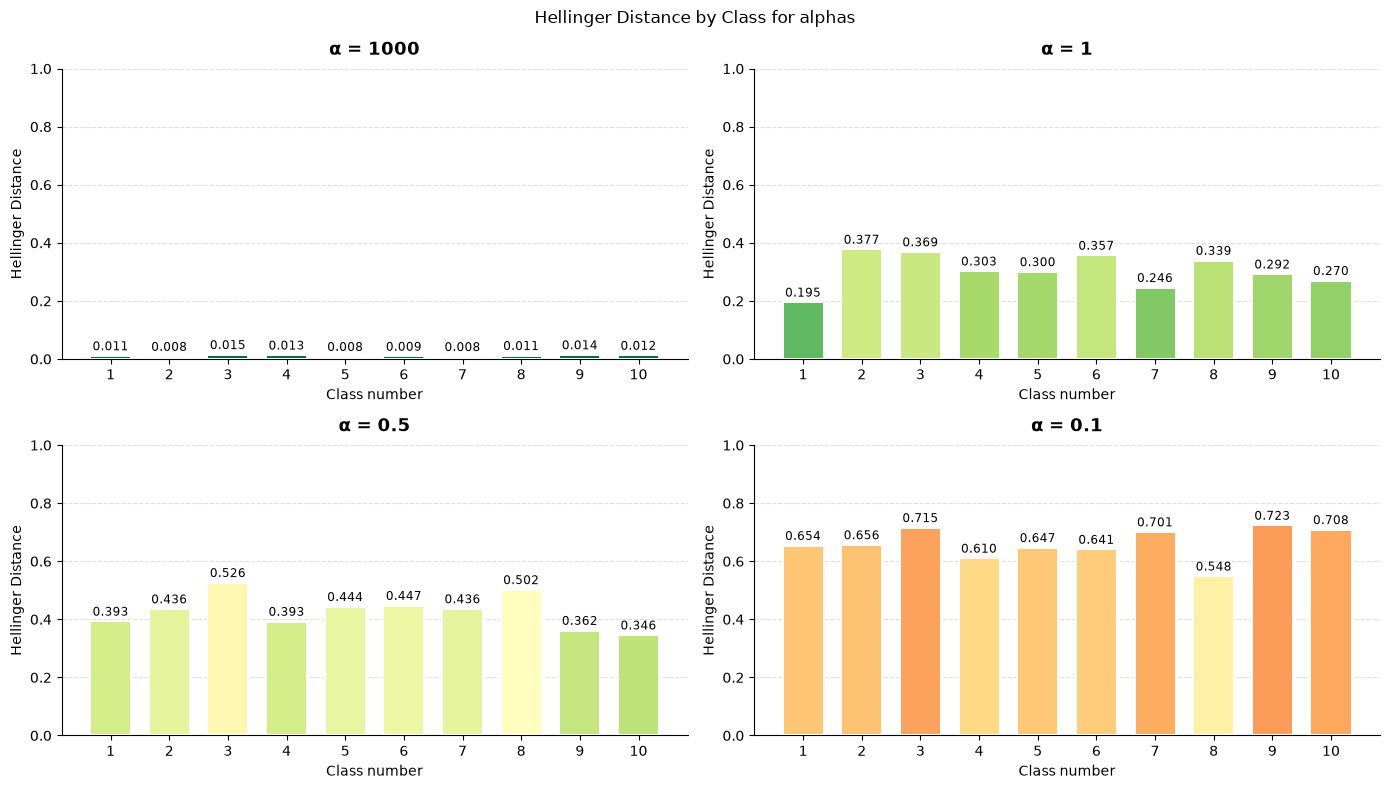

In [64]:
fig, axs = plt.subplots(2, 2, figsize=(14, 8))
cmap = plt.get_cmap('RdYlGn_r')
norm = mcolors.Normalize(vmin=0, vmax=1)

for i, (alpha, p) in enumerate(alphas_class_distributions.items()):

    row = i // 2
    col = i % 2
    ax = axs[row, col]

    hd_results = []

    for j in range(10):
        hd_results.append(HellingerDistance(p[j].numpy().tolist(), baseline))


    colors = [cmap(norm(v)) for v in hd_results]

    bar_container = ax.bar(
        range(1, 11), hd_results,
        color=colors, edgecolor='white', linewidth=1.4, width=0.7,
        zorder=3
    )
    ax.set_title(f'α = {alpha}', fontsize=13, fontweight='bold', pad=10)
    ax.set_ylabel('Hellinger Distance', fontsize=10)
    ax.set_xlabel('Class number', fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_xticks(range(1, 11))

    ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.bar_label(bar_container, fmt='%.3f', fontsize=8.5, padding=2)

plt.suptitle("Hellinger Distance by Class for alphas")
plt.tight_layout()
plt.show()


We can see how higher concentrations (alpha values) mean fairer distributions in our datasets 

#### 2. Earth Mover's Distance (EMD)

This measurement quantifies the dissimilarity between the frequency distributions, the main idea is that it measures not only the concentration but the position of the distributions (geometrically aware), this of course means that high-dimensional spaces can make this metric too heavy to use.

However our case study raises the issue of having a plane that would represent a discrete and non-quantifiable variable in terms of the label difference (meaning that even if class 1 is numerically closer to class 2 they are not necessarily similar), so we need to performa 1D study, for that we'll use

$$\text{EMD}(p,q) = \sum^{C}_{c=1}{|F_p(c) - F_q(c)|}$$

$$F_p(c) = \sum_{i \leq c} p_i$$

In [21]:
def EMD(p,q,class_count):
    sum = 0
    for c in range(class_count):
        sumpc = np.sum(p[0:c])
        sumqc = np.sum(q[0:c])
        sum += abs(sumpc - sumqc)
    
    return sum

In this scenario we want to compare each client versus the centralized model for all classes

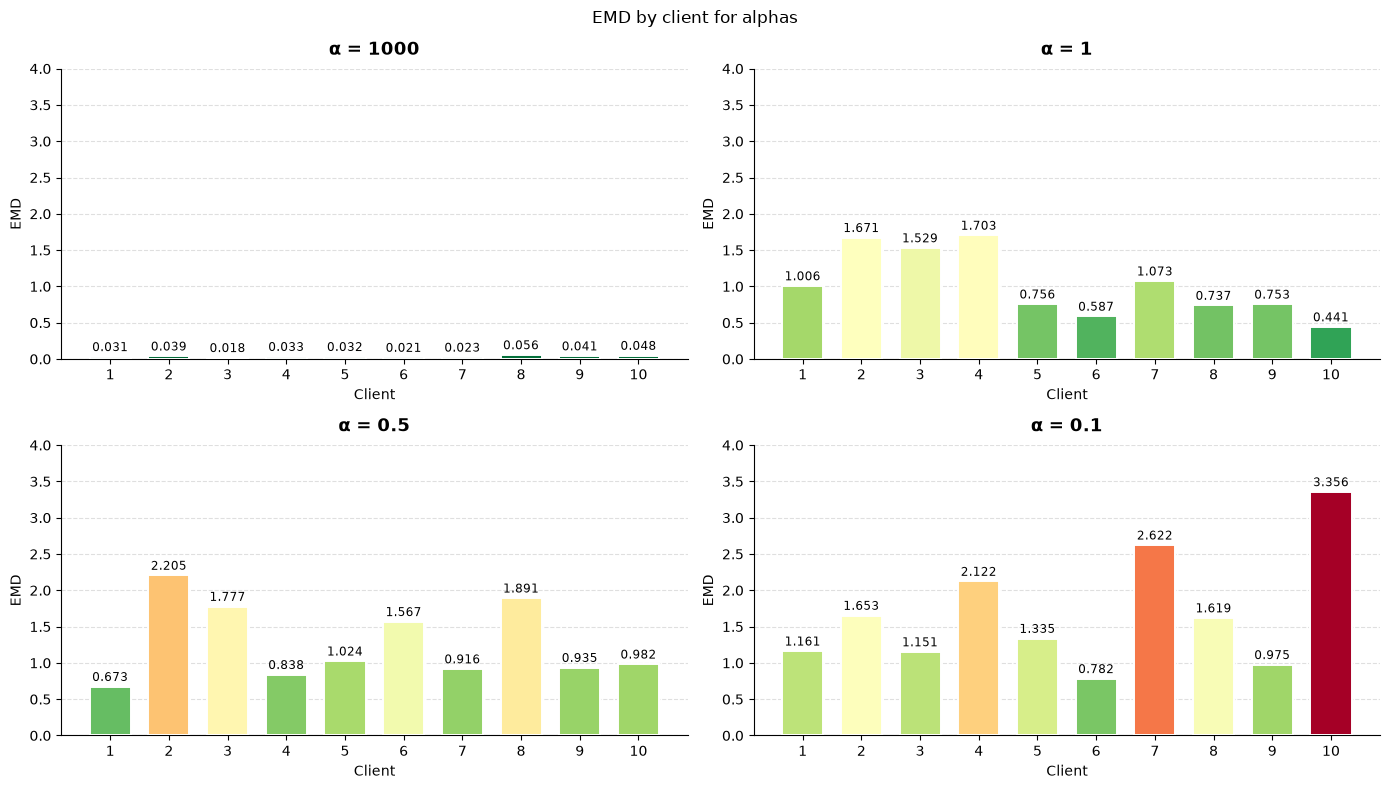

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(14, 8))
cmap = plt.get_cmap('RdYlGn_r')

all_emd_results = {
    alpha: [EMD(client_class_distribution[j][alpha], baseline, 10) for j in range(K)]
    for alpha in alphas_class_distributions
}
global_max = max(v for results in all_emd_results.values() for v in results)
norm = mcolors.Normalize(vmin=0, vmax=global_max) 


for i, (alpha, p) in enumerate(alphas_class_distributions.items()):
    row, col = i // 2, i % 2
    ax = axs[row, col]

    emd_results = [EMD(client_class_distribution[j][alpha], baseline, 10) for j in range(K)]

    colors = [cmap(norm(v)) for v in emd_results]

    bar_container = ax.bar(range(1, 11), emd_results, color=colors, edgecolor='white',
                            linewidth=1.4, width=0.7, zorder=3)
    ax.set_title(f'α = {alpha}', fontsize=13, fontweight='bold', pad=10)
    ax.set_ylabel('EMD', fontsize=10)
    ax.set_xlabel('Client', fontsize=10)
    ax.set_xticks(range(1, 11))
    ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
    ax.set_axisbelow(True)
    ax.set_ylim(0, 4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.bar_label(bar_container, fmt='%.3f', fontsize=8.5, padding=2)

plt.suptitle("EMD by client for alphas")
plt.tight_layout()
plt.show()

We can see some clear patterns across all alphas, even if they have different value magnitudes they almost always have some clients with high label skewness (remember that we are comparing each individual client's class distribution difference versus an ideal baseline scenario). <br> What that means is that some clients are bound to produce biased models when some classes are under/overrepresented, although when EMD values are so low the difference between clients is insignificant because of how similar they are to the ideal case.

#### 3. Jensen-Shannon divergence (JSD)


$$\text{JSD(p,q)} = \frac{1}{2}D_{KL}(p||m) + \frac{1}{2}D_{KL}(q||m), \quad m=\frac{1}{2}(p+q)$$

Where near-zero values mean closer to IID distributions

Although technically not a metric, it does give us some idea of how identical two distributions are. What it does is utilize the [Kullback-Leibler divergence](https://en.wikipedia.org/wiki/Kullback%E2%80%93Leibler_divergence) which measures how much an approximation is different from a true probability distribution.

In [25]:
def D_kl(p,q):
    sum = 0
    for i in range(len(p)):
        if p[i] == 0:
            continue
        sum += p[i] * math.log(p[i]/q[i])
    return sum

def JSD(p,q):
    p = np.array(p)
    q = np.array(q)
    m = 0.5 * (p + q)
    return 0.5 * (D_kl(p,m) + D_kl(q,m))

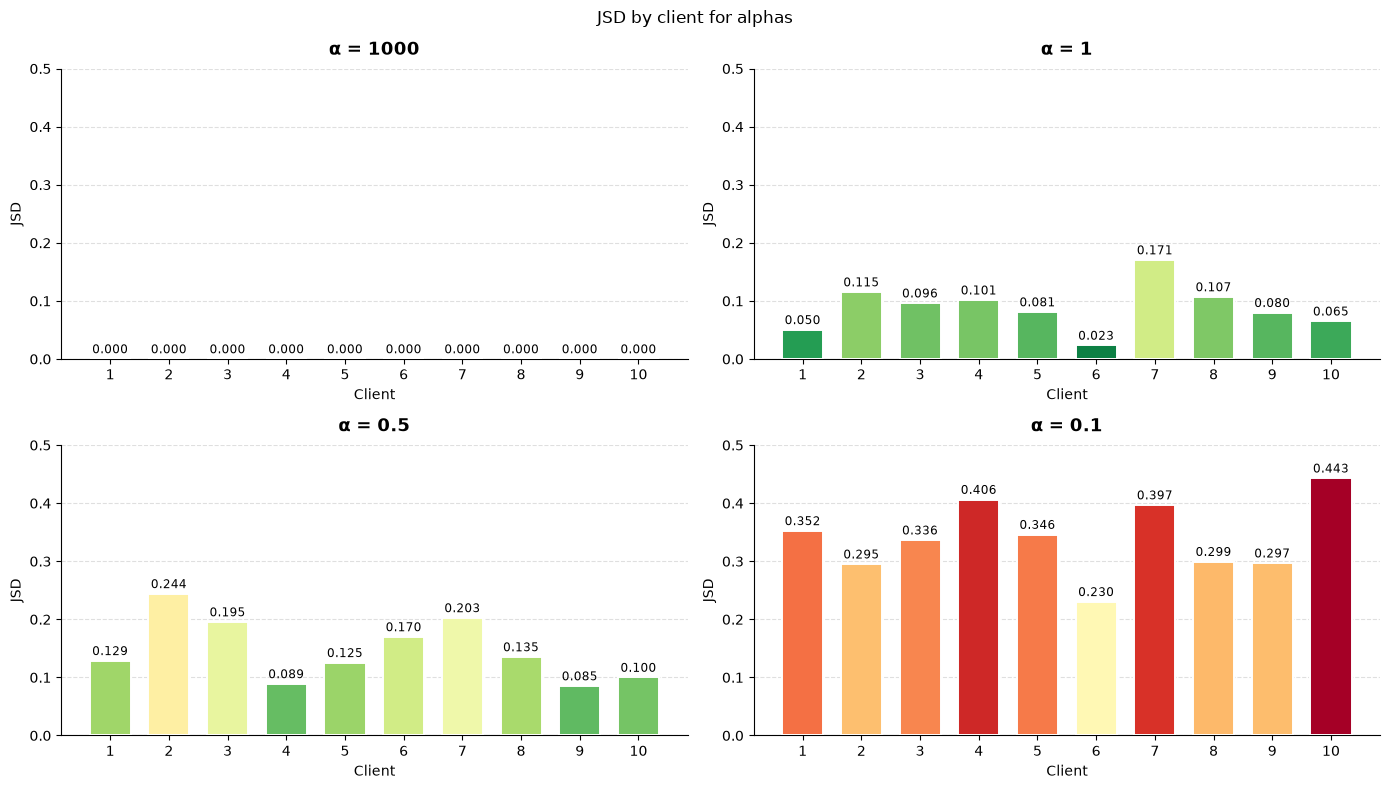

In [31]:
fig, axs = plt.subplots(2, 2, figsize=(14, 8))
cmap = plt.get_cmap('RdYlGn_r')

all_jsd_results = {
    alpha: [JSD(client_class_distribution[j][alpha], baseline) for j in range(K)]
    for alpha in alphas_class_distributions
}
global_max = max(v for results in all_jsd_results.values() for v in results)
norm = mcolors.Normalize(vmin=0, vmax=global_max) 

client_class_distribution = {}

def normalize(counts):
    total = sum(counts)
    return [c / total for c in counts] if total else [0.0] * len(counts)

client_class_distribution = {
    i: {alpha: normalize(alpha_client_class_counts[alpha][i]) for alpha in alphas_class_distributions}
    for i in range(K)
}
    

for i, (alpha, p) in enumerate(alphas_class_distributions.items()):
    row, col = i // 2, i % 2
    ax = axs[row, col]

    jsd_results = all_jsd_results[alpha]

    colors = [cmap(norm(v)) for v in jsd_results]

    bar_container = ax.bar(range(1, 11), jsd_results, color=colors, edgecolor='white',
                            linewidth=1.4, width=0.7, zorder=3)
    ax.set_title(f'α = {alpha}', fontsize=13, fontweight='bold', pad=10)
    ax.set_ylabel('JSD', fontsize=10)
    ax.set_xlabel('Client', fontsize=10)
    ax.set_xticks(range(1, 11))
    ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
    ax.set_axisbelow(True)
    ax.set_ylim(0,0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.bar_label(bar_container, fmt='%.3f', fontsize=8.5, padding=2)

plt.suptitle("JSD by client for alphas")
plt.tight_layout()
plt.show()

#### 4. Population Stability Index

Source: [PSI](https://arxiv.org/pdf/2512.20363)

$$PSI = \sum_{c=1}^{C}{(P(y=c) - P_i(y=c))ln(\frac{P(y=c)}{P_i(y=c)})}$$

In our test case however we can take advantage of the fact that our baseline dataset is equally distributed w/ 10% samples per class, thus reducing the PSI formula to

$$PSI = \sum_{c=1}^{C}{(10\% - P_i(y=c))ln(\frac{10\%}{P_i(y=c)})}$$



In [52]:
def PSI(P_i):
    sum = 0
    for c in range(10):
        if P_i[c] != 0:
            sum += (0.1 - P_i[c]) * math.log(0.1/P_i[c])
        else:
             sum += (0.1 - P_i[c]) * math.log(0.1/0.000001)
    return sum

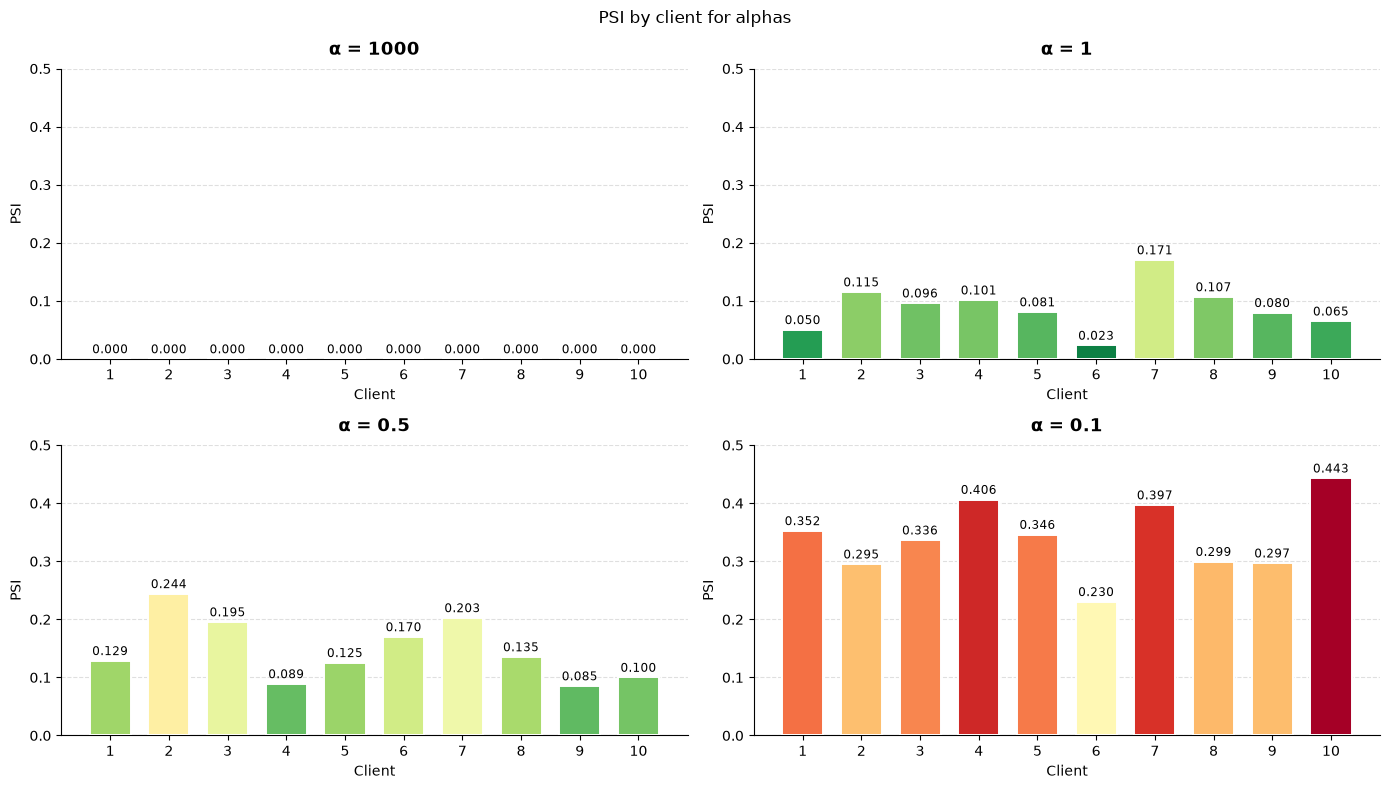

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(14, 8))
cmap = plt.get_cmap('RdYlGn_r')

all_psi_results = {
    alpha: [JSD(client_class_distribution[j][alpha], baseline) for j in range(K)]
    for alpha in alphas_class_distributions
}

global_max = max(v for results in all_psi_results.values() for v in results)
norm = mcolors.Normalize(vmin=0, vmax=global_max) 


for i, (alpha, p) in enumerate(alphas_class_distributions.items()):
    row, col = i // 2, i % 2
    ax = axs[row, col]

    psi_results = all_psi_results[alpha]

    colors = [cmap(norm(v)) for v in psi_results]

    bar_container = ax.bar(range(1, 11), psi_results, color=colors, edgecolor='white',
                            linewidth=1.4, width=0.7, zorder=3)
    ax.set_title(f'α = {alpha}', fontsize=13, fontweight='bold', pad=10)
    ax.set_ylabel('PSI', fontsize=10)
    ax.set_xlabel('Client', fontsize=10)
    ax.set_xticks(range(1, 11))
    ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
    ax.set_axisbelow(True)
    ax.set_ylim(0,0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.bar_label(bar_container, fmt='%.3f', fontsize=8.5, padding=2)

plt.suptitle("PSI by client for alphas")
plt.tight_layout()
plt.show()


### Local Models training

Having the local datasets we can train each of the client's models and see their performance across the Adam & SGD optimizers

#### Adam-Optimized Models

In [ ]:
best_performing_clients_Adam = {}

for alpha, clients_datasets in alpha_clients_datasets.items(): #For all densities

    clients_Adam_metrics = []

    for client_index in range(K):  # For each client

        # We define a model using Adam optimizer
        Adam_model = copy.deepcopy(initial_model)
        Adam_optimizer = torch.optim.Adam(Adam_model.parameters())

        client_train_loader = DataLoader(clients_datasets[client_index]["train"], batch_size=32, shuffle=True)
        client_val_loader = DataLoader(clients_datasets[client_index]["val"], batch_size=32, shuffle=True)

        # We keep themetrics
        clients_Adam_metrics.append(run_model(Adam_model, Adam_optimizer, epochs=epochs, train_dataloader=client_train_loader, val_dataloader=client_val_loader))

    # We pick the client w/ max accuracy 
    best_client_index, (best_train_metrics, best_val_metrics) = max(
        enumerate(clients_Adam_metrics),
        key=lambda item: item[1][1][-1][0]  
    )

    best_performing_clients_Adam[alpha] = {
        "client_index": best_client_index,
        "train_metrics": best_train_metrics,
        "val_metrics": best_val_metrics
    }


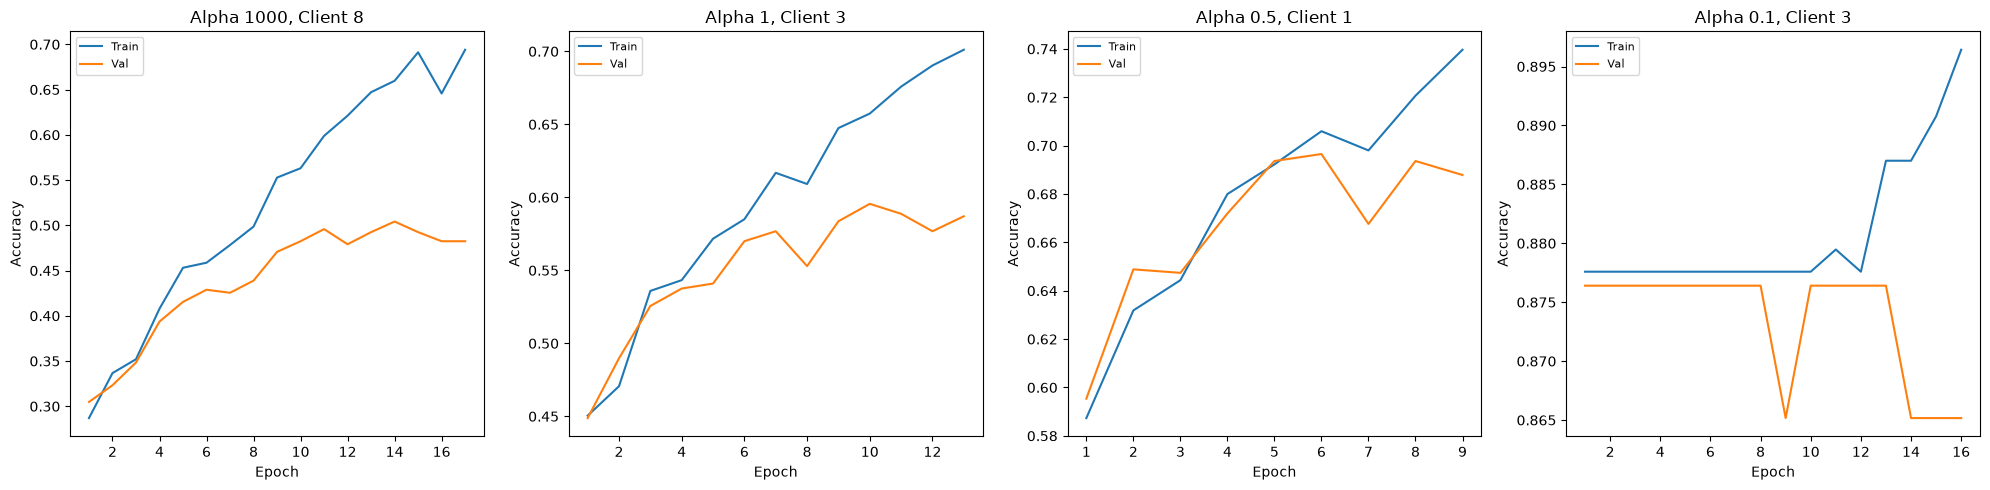

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20,5))

for i,(alpha, dict) in enumerate(best_performing_clients_Adam.items()):
    client_index = dict["client_index"]
    train_metrics, val_metrics = dict["train_metrics"], dict["val_metrics"]
    train_acc = [acc for acc, loss in train_metrics]
    val_acc = [acc for acc, loss in val_metrics]
    epochs_range = range(1, len(train_acc) + 1)

    ax = axes[i]
    ax.plot(epochs_range, train_acc, label="Train", color="tab:blue")
    ax.plot(epochs_range, val_acc, label="Val", color="tab:orange")
    ax.set_title(f"Alpha {alpha}, Client {client_index}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

#### SGD-Optimized Models

In [ ]:
best_performing_clients_SGD = {}

for alpha, clients_datasets in alpha_clients_datasets.items(): #For all densities

    clients_SGD_metrics = []

    for client_index in range(K):  # For each client

        # We define a model using SGD optimizer
        SGD_model = copy.deepcopy(initial_model)
        SGD_optimizer = torch.optim.SGD(SGD_model.parameters())

        client_train_loader = DataLoader(clients_datasets[client_index]["train"], batch_size=32, shuffle=True)
        client_val_loader = DataLoader(clients_datasets[client_index]["val"], batch_size=32, shuffle=True)

        # We keep the metrics
        clients_SGD_metrics.append(run_model(SGD_model, SGD_optimizer, epochs=epochs, train_dataloader=client_train_loader, val_dataloader=client_val_loader))

    # We pick the client w/ max accuracy 
    best_client_index, (best_train_metrics, best_val_metrics) = max(
        enumerate(clients_SGD_metrics),
        key=lambda item: item[1][1][-1][0]  
    )

    best_performing_clients_SGD[alpha] = {
        "client_index": best_client_index,
        "train_metrics": best_train_metrics,
        "val_metrics": best_val_metrics
    }


In [ ]:
np.average(clients_Adam_metrics)

## Federated Learning Aggregation Strategies

